In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter

# --- Load the dataset ---
# file_path = "collision_dataset_100000_H2.csv"
file_path = "collision_dataset_100000_H2_DSMC_sampling.csv"
# file_path = "LB_collision_data.csv"


# Try space-delimited first; if that fails, fall back to commas
df = pd.read_csv(file_path, sep=",")

# create test set
data = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the data
data, data_test = data.iloc[:70000], data.iloc[70000:].reset_index(drop=True)

# --- Basic info ---
print("Columns:", data.columns.tolist())
print("First few rows:")
print(data.head())

Columns: ['b', 'Etr', 'Er1', 'Er2', 'Etrp', 'Er1p', 'Er2p', 'Teq']
First few rows:
          b          Etr         Er1          Er2         Etrp        Er1p  \
0  0.042053  1592.685382  160.533045  1307.790673  1386.537360  128.841854   
1  0.497317   605.821433   56.487030   974.134069   636.023095   99.810584   
2  0.847443   309.061943  216.389502   334.260884   309.078690  198.436951   
3  1.141467   261.398550   65.673065   732.889434   294.313670   54.369180   
4  0.204248  1565.764246  155.516061    69.610367  1026.361270  631.884538   

          Er2p         Teq  
0  1545.530534  543.636792  
1   900.515140  831.424962  
2   352.114107  157.640946  
3   711.208547  490.005401  
4   132.546979  408.444094  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


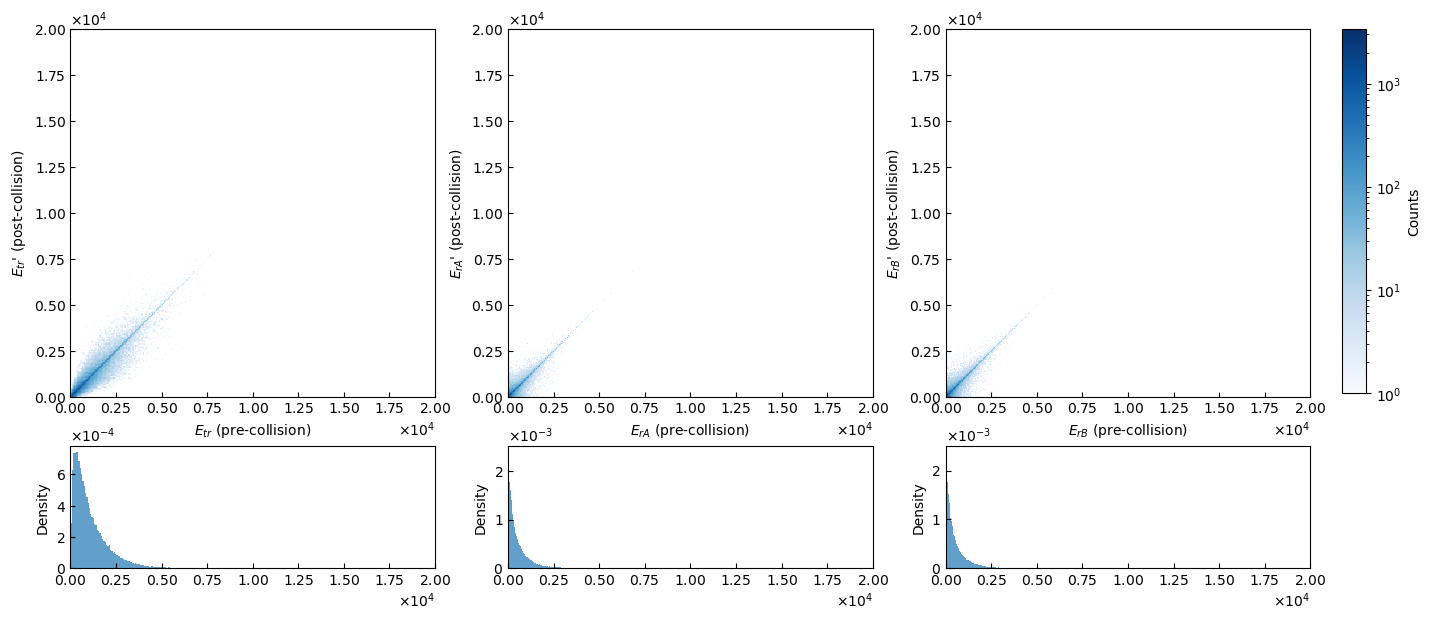

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LogNorm
import numpy as np
from scipy.stats import uniform

bins = 200

# --- Common color scale for 2D histograms ---
h_t, _, _ = np.histogram2d(data["Etr"], data["Etrp"], bins=bins)
h_rA, _, _ = np.histogram2d(data["Er1"], data["Er1p"], bins=bins)
h_rB, _, _ = np.histogram2d(data["Er2"], data["Er2p"], bins=bins)
vmin = max(1, min(h_t[h_t>0].min(), h_rA[h_rA>0].min(), h_rB[h_rB>0].min()))
vmax = max(h_t.max(), h_rA.max(), h_rB.max())

fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.2, wspace=0.2)

xs_Etr = np.linspace(100, 6000, 1000)
xs_Er = np.linspace(0, 3000, 1000)

variables = [("Etr","Etrp", xs_Etr, 0, 20000, r"$E_{tr}$"),
             ("Er1","Er1p", xs_Er, 0, 20000, r"$E_{rA}$"),
             ("Er2","Er2p", xs_Er, 0, 20000, r"$E_{rB}$")]

for i, (xvar, yvar, xs, xmin, xmax, label) in enumerate(variables):
    # Top row: 2D histogram
    ax = fig.add_subplot(gs[0, i])
    h = ax.hist2d(data[xvar], data[yvar],
                  bins=bins, norm=LogNorm(vmin=vmin, vmax=vmax),
                  cmap='Blues')
    ax.set_xlabel(f"{label} (pre-collision)")
    ax.set_ylabel(f"{label}' (post-collision)")
    ax.tick_params(direction='in')
    #ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, xmax)
    ax.legend(facecolor='white', framealpha=1.0, loc='upper left', edgecolor='white')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    # Bottom row: 1D histogram (pre-collision)
    ax = fig.add_subplot(gs[1, i])
    ax.hist(data[xvar], bins=bins, density=True, alpha=0.7)
    pdf = uniform.pdf(xs, xmin, xmax)
    # ax.plot(xs, pdf, '-', color="C3", lw=2, label=f"Uniform({xmin},{xmax})")
    # ax.set_xlabel(f"{label} (pre-collision)")
    ax.set_ylabel("Density")
    # ax.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
    ax.tick_params(direction='in')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.set_xlim(0, xmax)

# Shared colorbar for all 2D histograms
cbar_ax = fig.add_axes([0.92, 0.36, 0.015, 0.52])  # [left, bottom, width, height]
fig.colorbar(h[3], cax=cbar_ax, label="Counts")

plt.show()

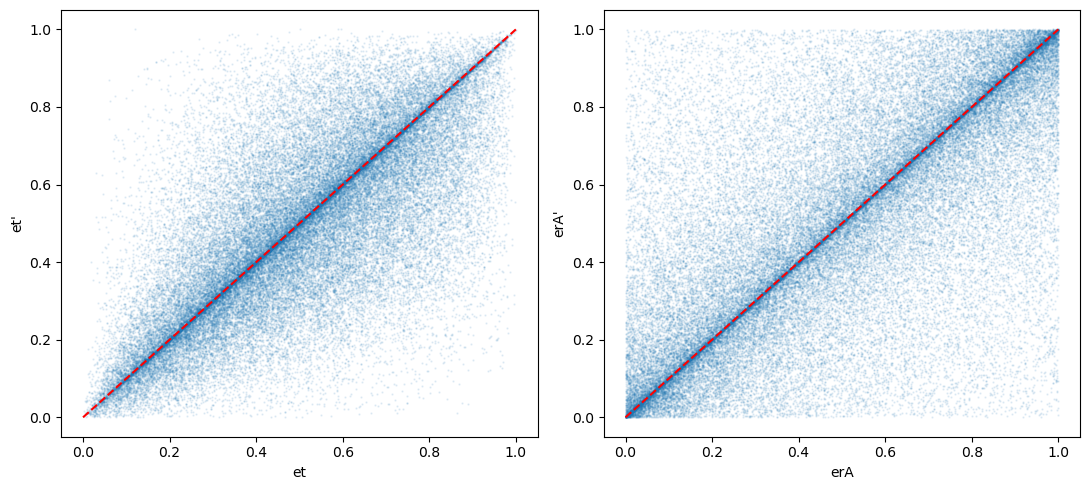

In [8]:
import os
import math
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax import random, jit, value_and_grad
from jax.example_libraries import stax, optimizers
import matplotlib.pyplot as plt

# -------------------------- Utilities --------------------------
def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_logit(z):
    return jnp.clip(1.0 / (1.0 + jnp.exp(-z)), 1e-12, 1 - 1e-12)

def preprocess_df(df):
    """
    Preprocess according to the paper's variable definitions:
    - Ec: total collision energy
    - eps_t: translational energy fraction  
    - eps_r_A: rotational energy fraction for molecule A
    """
    # Epsilon to prevent division by zero if total rotational energy is zero
    epsilon = 1e-12

    # --- Pre-collision values ---
    Etr = df["Etr"].values
    Er1 = df["Er1"].values
    Er2 = df["Er2"].values
    
    Ec = Etr + Er1 + Er2
    E_rot_total = Er1 + Er2
    
    # Calculate energy fractions (precollisional)
    eps_t = Etr / (Ec + epsilon)
    eps_r_A = Er1 / (E_rot_total + epsilon)
    
    # --- Post-collision values (for training targets) ---
    Etrp = df["Etrp"].values
    Er1p = df["Er1p"].values
    Er2p = df["Er2p"].values
    
    # Post-collision Ec is the same as pre-collision Ec
    E_rot_p_total = Er1p + Er2p

    # Calculate postcollisional energy fractions (targets)
    eps_t_prime = Etrp / (Ec + epsilon)
    eps_r_A_prime = Er1p / (E_rot_p_total + epsilon)
    
    # Apply transformations as per Equation 4.15
    x = np.stack([
        np.log(Ec + epsilon),      # E_c^(p)
        logit(eps_t),              # eps_t^(p) 
        logit(eps_r_A),            # eps_r,A^(p)
        # np.exp(df["b"].values),     # b^(p)  # Uncomment if including impact parameter
        #df["Teq"].values
    ], axis=-1)
    
    y = np.stack([
        logit(eps_t_prime),        # eps_t'^(p)
        logit(eps_r_A_prime)       # eps_r,A'^(p)
    ], axis=-1)
    
    return x.astype(np.float32), y.astype(np.float32), Ec

# -------------------------- Load and split dataset --------------------------
X, Y, Ec = preprocess_df(data)
X_test, Y_test, Ec_test = preprocess_df(data_test)
N = X.shape[0]


X_train, Y_train = X, Y
X_val, Y_val = X_test, Y_test
X_test, Y_test = X_test, Y_test

plt.figure(figsize=[11,5])

plt.subplot(1,2,1)
plt.xlabel("et")
plt.ylabel("et'")
plt.scatter(inv_logit(X_train[:, 1]), inv_logit(Y_train[:, 0]), s=0.5, alpha=0.1)
plt.plot([0,1], [0, 1], color='red', linestyle='--')

plt.subplot(1,2,2)
plt.xlabel("erA")
plt.ylabel("erA'")
plt.scatter(inv_logit(X_train[:, 2]), inv_logit(Y_train[:, 1]), s=0.5, alpha=0.1)
plt.plot([0,1], [0, 1], color='red', linestyle='--')
plt.tight_layout()
plt.show()

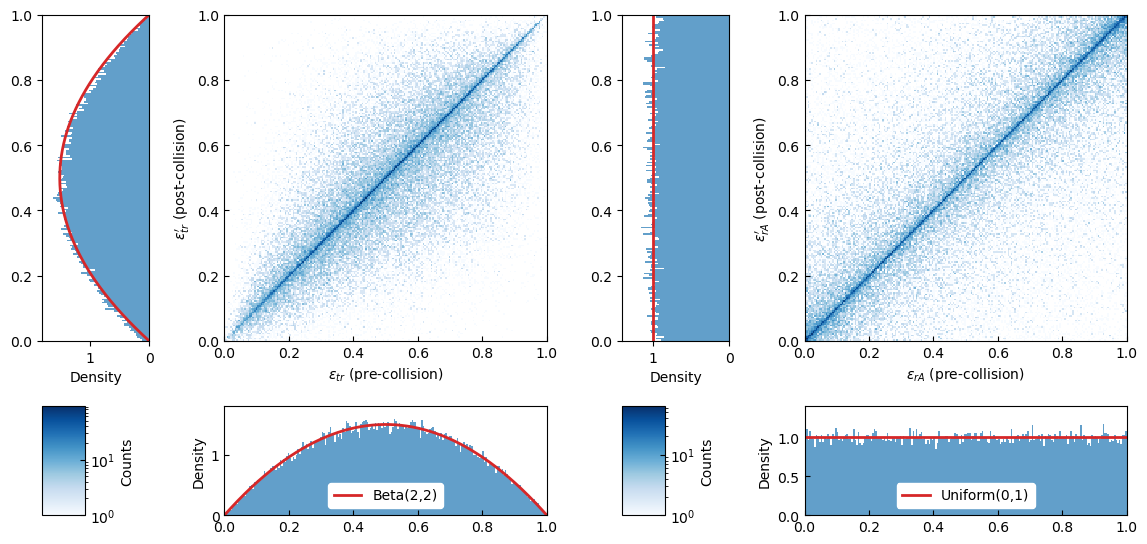

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy.stats import beta, uniform

# Data (your variables)
x_tr = inv_logit(X_train[:, 1])         # pre-collision translational
y_tr = inv_logit(Y_train[:, 0])         # post-collision translational
x_rot = inv_logit(X_train[:, 2])        # pre-collision rotational
y_rot = inv_logit(Y_train[:, 1])        # post-collision rotational

xs = np.linspace(0, 1, 1000)

# Figure + GridSpec:
fig = plt.figure(figsize=(14, 6.5))
# Make thin margin columns small and 2D columns large
grid = fig.add_gridspec(2, 4,
                        width_ratios=[1, 3.0, 1, 3.0],
                        height_ratios=[3.0, 1],
                        hspace=0.3, wspace=0.35)


# ---- create the 2D panels first so we can share y with the left marginal ----
ax2 = fig.add_subplot(grid[0, 1])   # top-row, 2D translational
h1 = ax2.hist2d(x_tr, y_tr, bins=200, norm=LogNorm(), cmap='Blues')
ax2.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax2.set_ylabel(r"$\varepsilon_{tr}'$ (post-collision)")
ax2.tick_params(direction='in')
#ax2.set_box_aspect(1)   # keep square
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

ax4 = fig.add_subplot(grid[0, 3])   # top-row, 2D rotational
h2 = ax4.hist2d(x_rot, y_rot, bins=200, norm=LogNorm(), cmap='Blues')
ax4.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax4.set_ylabel(r"$\varepsilon_{rA}'$ (post-collision)")
ax4.tick_params(direction='in')
#ax4.set_box_aspect(1)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

# colorbars (adjust fraction/pad so they don't shrink the axes)

# === COLORBARS in bottom row (cols 0 and 2, thinner) ===
ax_cb1 = fig.add_subplot(grid[1, 0])
ax_cb2 = fig.add_subplot(grid[1, 2])

# Create horizontal colorbars with thinner height
cb1 = fig.colorbar(h1[3], cax=ax_cb1, orientation='vertical')
cb2 = fig.colorbar(h2[3], cax=ax_cb2, orientation='vertical')

# Make the colorbars thinner by reducing their width
for cb_ax in [cb1.ax, cb2.ax]:
    pos = cb_ax.get_position()
    # pos = [x0, y0, width, height]
    cb_ax.set_position([pos.x0, pos.y0, 0.4*pos.width, pos.height])

cb1.set_label("Counts")
cb2.set_label("Counts")

# Make ticks point inward
for cb_ax in [ax_cb1, ax_cb2]:
    cb_ax.tick_params(direction='in')


# ---- Top-row thin marginals (horizontal, share y with respective 2D axes) ----
# Left top: post-collision translational (horizontal), share y with ax2
ax1 = fig.add_subplot(grid[0, 0], sharey=ax2)
# horizontal histogram along y; orientation='horizontal'
ax1.hist(y_tr, bins=200, density=True, alpha=0.7, orientation='horizontal')
# plot PDF: for horizontal orientation plot pdf on x vs xs on y
ax1.plot(beta.pdf(xs, 2, 2), xs, '-', color="C3", lw=2, label='Beta(2,2)')
ax1.set_ylim(0, 1)
ax1.set_xlim(0, 1.8)
# invert x so bars extend *towards* the 2D plot
ax1.invert_xaxis()
ax1.set_xlabel("Density")


# Right top: post-collision rotational (horizontal), share y with ax4
ax3 = fig.add_subplot(grid[0, 2], sharey=ax4)
ax3.hist(y_rot, bins=200, density=True, alpha=0.7, orientation='horizontal')
ax3.plot(uniform.pdf(xs, 0, 1), xs, '-', color="C3", lw=2, label='Uniform(0,1)')
ax3.set_ylim(0, 1)
ax3.set_xlim(0, 1.4)
ax3.invert_xaxis()
ax3.set_xlabel("Density")


# ---- Bottom row: thin 1D histograms (pre-collision), keep them horizontal? vertically oriented is fine ----
# Column 2 (bottom middle-left): pre-collision translational
ax5 = fig.add_subplot(grid[1, 1], sharex=ax2)
ax5.hist(x_tr, bins=200, density=True, alpha=0.7)
ax5.plot(xs, beta.pdf(xs, 2, 2), '-', color="C3", lw=2, label="Beta(2,2)")
# ax5.plot(beta.pdf(xs, 2, 2)*-1, xs, '-', color="orange", lw=2, label='Beta(2,2)')
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1.8)
# ax5.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax5.set_ylabel("Density")
ax5.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax5.tick_params(direction='in')

# Column 4 (bottom right): pre-collision rotational
ax6 = fig.add_subplot(grid[1, 3], sharex=ax2)
ax6.hist(x_rot, bins=200, density=True, alpha=0.7)
ax6.plot(xs, uniform.pdf(xs, 0, 1), '-', color="C3", lw=2, label="Uniform(0,1)")
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1.4)
# ax6.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax6.set_ylabel("Density")
ax6.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax6.tick_params(direction='in')

plt.show()

# symmetric GMM

In [14]:
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm, multivariate_normal
import matplotlib.pyplot as plt
from tqdm.notebook import trange # For a nice progress bar


class SymmetricGMM:
    """
    A Gaussian Mixture Model symmetric around the x=y line, trainable with EM.
    """
    def __init__(self):
        """Initializes the model. Parameters will be set after fitting."""
        self.weights = None
        self.means = None
        self.covariances = None
        self.n_base_components = None
        self.n_components = None
        self.converged_ = False
        self.log_likelihood_history_ = []

    def fit(self, X, n_base_components, n_iterations=100, tol=1e-4, reg_covar=1e-6, key=jax.random.PRNGKey(0)):
        """
        Fits the GMM to the data using a symmetric Expectation-Maximization algorithm.

        Args:
            X (jnp.ndarray): The training data, shape (n_samples, 2).
            n_base_components (int): The number of symmetric modes (K). The total
                                     number of components will be 2*K.
            n_iterations (int): The maximum number of EM iterations.
            tol (float): The convergence threshold for the log-likelihood.
            reg_covar (float): A small value added to the diagonal of covariances
                               to ensure they are non-singular.
            key (jax.random.PRNGKey): JAX random key for initialization.

        Returns:
            self: The fitted model instance.
        """
        self.n_base_components = n_base_components
        n_samples = X.shape[0]

        # 1. Initialize base parameters
        key, subkey = jax.random.split(key)
        base_weights, base_means, base_covariances = self._initialize_params(X, subkey)

        prev_log_likelihood = -jnp.inf
        
        pbar = trange(n_iterations, desc="EM Iterations")
        for i in pbar:
            # Create full symmetric parameters from base
            self.weights, self.means, self.covariances = self._create_symmetric_params(
                base_weights, base_means, base_covariances
            )
            self.n_components = len(self.weights)

            # 2. E-Step: Calculate responsibilities and log-likelihood
            log_responsibilities, log_likelihood = self._e_step(X)
            responsibilities = jnp.exp(log_responsibilities)
            self.log_likelihood_history_.append(log_likelihood)

            # 3. M-Step: Update base parameters using symmetric update rules
            base_weights, base_means, base_covariances = self._m_step(X, responsibilities, reg_covar)
            
            # Check for convergence
            change = log_likelihood - prev_log_likelihood
            pbar.set_postfix({"Log-Likelihood": f"{log_likelihood:.4f}", "Change": f"{change:.4f}"})
            if jnp.abs(change) < tol:
                self.converged_ = True
                pbar.close()
                print(f"Converged after {i+1} iterations.")
                break
            prev_log_likelihood = log_likelihood

        if not self.converged_:
            print("EM algorithm did not converge within the specified number of iterations.")

        return self

    def _initialize_params(self, X, key):
        """Initializes the K base parameters."""
        n_samples = X.shape[0]
        
        # Initialize means by randomly picking K points from the data
        initial_means = jax.random.choice(key, X, shape=(self.n_base_components,), replace=False)
        
        # Initialize weights uniformly
        initial_weights = jnp.full(self.n_base_components, 1.0 / (2 * self.n_base_components))
        
        # Initialize covariances as identity matrices
        initial_covs = jnp.repeat(jnp.eye(2)[None, :, :], self.n_base_components, axis=0)
        
        return initial_weights, initial_means, initial_covs

    def _create_symmetric_params(self, weights, means, covs):
        """Constructs the full set of symmetric parameters."""
        flipped_means = jnp.fliplr(means)
        flipped_covs = covs.at[:, [0, 1], [0, 1]].set(covs[:, [1, 0], [1, 0]])
        full_weights = jnp.concatenate([weights, weights])
        full_means = jnp.concatenate([means, flipped_means], axis=0)
        full_covariances = jnp.concatenate([covs, flipped_covs], axis=0)
        return full_weights, full_means, full_covariances

    def _create_symmetric_params(self, weights, means, covs):
        """Constructs the full set of point-symmetric parameters around the origin."""
        # Reflect means through the origin
        flipped_means = -means

        # Covariances are unchanged under point symmetry
        flipped_covs = covs

        # Duplicate weights for symmetric counterparts
        full_weights = jnp.concatenate([weights, weights])
        full_means = jnp.concatenate([means, flipped_means], axis=0)
        full_covariances = jnp.concatenate([covs, flipped_covs], axis=0)

        return full_weights, full_means, full_covariances
        

    def _e_step(self, X):
        """Performs the E-step of the algorithm."""
        log_prob_norm = jax.vmap(
            lambda mu, cov: multivariate_normal.logpdf(X, mu, cov)
        )(self.means, self.covariances).T
        
        weighted_log_prob = log_prob_norm + jnp.log(self.weights)
        log_prob_total = jax.scipy.special.logsumexp(weighted_log_prob, axis=1)
        log_responsibilities = weighted_log_prob - log_prob_total[:, None]
        
        return log_responsibilities, jnp.sum(log_prob_total)

    def _m_step(self, X, responsibilities, reg_covar):
        """Performs the symmetric M-step of the algorithm."""
        n_samples = X.shape[0]
        K = self.n_base_components
        
        # Split responsibilities for base and flipped components
        r_base = responsibilities[:, :K]
        r_flipped = responsibilities[:, K:]
        
        # Sum of responsibilities for each pair
        R_pair = r_base.sum(axis=0) + r_flipped.sum(axis=0)

        # Update base weights
        new_base_weights = R_pair / (2 * n_samples)
        
        # Update base means
        X_flipped = jnp.fliplr(X)
        num_means = jnp.dot(r_base.T, X) + jnp.dot(r_flipped.T, X_flipped)
        new_base_means = num_means / (R_pair[:, None] + 1e-6)
        
        # Update base covariances (vectorized)
        def update_cov_k(k):
            diff_base = X - new_base_means[k]
            diff_flipped = X_flipped - new_base_means[k]
            num_cov_base = jnp.dot(diff_base.T * r_base[:, k], diff_base)
            num_cov_flipped = jnp.dot(diff_flipped.T * r_flipped[:, k], diff_flipped)
            cov_k = (num_cov_base + num_cov_flipped) / (R_pair[k] + 1e-6)
            # Add regularization
            cov_k += jnp.eye(2) * reg_covar
            return cov_k
            
        new_base_covariances = jax.vmap(update_cov_k)(jnp.arange(K))
        
        return new_base_weights, new_base_means, new_base_covariances
        
    def sample(self, key, n_samples):
        """Samples from the joint distribution p(x, y)."""
        key_choice, key_sample = jax.random.split(key)
        component_indices = jax.random.choice(key_choice, self.n_components, (n_samples,), p=self.weights)
        samples = jax.vmap(lambda k, s_key: jax.random.multivariate_normal(s_key, self.means[k], self.covariances[k]))(
            component_indices, jax.random.split(key_sample, n_samples)
        )
        return samples
    
    def conditional_sample(self, key, x_values):
        """
        Samples from the conditional distribution p(y|x) for given x values.

        Args:
            key (jax.random.PRNGKey): JAX random key.
            x_values (jnp.ndarray): A 1D array of x-values to condition on.

        Returns:
            jnp.ndarray: A 1D array of sampled y-values, one for each x_value.
        """
        # We use vmap to efficiently sample a y for each x
        # Create a unique key for each x value
        keys = jax.random.split(key, num=x_values.shape[0])

        # jit-compile the vmapped function for performance
        return jax.jit(jax.vmap(self._sample_single_y))(keys, x_values)

    def _sample_single_y(self, key, x_val):
        """Helper function to sample one y value for a single x value."""
        # 1. Calculate the responsibility of each component for the given x_val
        # p(k|x) ∝ p(x|k) * p(k)
        # We work in log-space for numerical stability

        # p(x|k) is the PDF of a 1D Gaussian (the marginal of the 2D Gaussian)
        mus_x = self.means[:, 0]
        vars_x = self.covariances[:, 0, 0]
        log_p_x_given_k = norm.logpdf(x_val, mus_x, jnp.sqrt(vars_x))

        # p(k) is the component weight
        log_p_k = jnp.log(self.weights)

        # Log of unnormalized responsibilities
        log_responsibilities = log_p_x_given_k + log_p_k

        # 2. Choose a component k based on these responsibilities
        key_choice, key_sample = jax.random.split(key)
        chosen_k = jax.random.categorical(key_choice, log_responsibilities)

        # 3. Sample y from the conditional distribution p(y|x, k) of the chosen component
        # For a multivariate normal, this conditional is also a normal distribution.
        mu_k = self.means[chosen_k]
        cov_k = self.covariances[chosen_k]

        # Parameters of the conditional Gaussian N(mu_y_cond, var_y_cond)
        # Using the standard formula for conditional Gaussians
        mu_y_cond = mu_k[1] + cov_k[1, 0] / (cov_k[0, 0] + 1e-6) * (x_val - mu_k[0])
        var_y_cond = cov_k[1, 1] - cov_k[1, 0] * cov_k[0, 1] / (cov_k[0, 0] + 1e-6)

        # Sample from this 1D Gaussian
        y_sample = mu_y_cond + jax.random.normal(key_sample) * jnp.sqrt(jnp.maximum(0, var_y_cond))

        return y_sample

    def conditional_expected_value(self, x_values):
            """
            Analytically compute E[y | x] for given x-values.

            Args:
                x_values (array): shape (N,)
            Returns:
                expected_y (array): shape (N,)
            """
            mus_x = self.means[:, 0]
            mus_y = self.means[:, 1]
            var_x = self.covariances[:, 0, 0]
            cov_xy = self.covariances[:, 1, 0]
            var_y = self.covariances[:, 1, 1]

            def single_x(x):
                # Compute log p(x|k)
                log_p_x_given_k = norm.logpdf(x, mus_x, jnp.sqrt(var_x))
                log_p_k = jnp.log(self.weights + 1e-12)
                log_r = log_p_x_given_k + log_p_k
                log_r -= jax.scipy.special.logsumexp(log_r)  # normalize
                r = jnp.exp(log_r)

                # Conditional means for each component
                mu_y_cond = mus_y + cov_xy / (var_x + 1e-8) * (x - mus_x)

                # Weighted sum gives the overall expected value
                return jnp.sum(r * mu_y_cond)

            # Vectorize for all x-values
            return jax.vmap(single_x)(x_values)     

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM algorithm did not converge within the specified number of iterations.


EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM algorithm did not converge within the specified number of iterations.


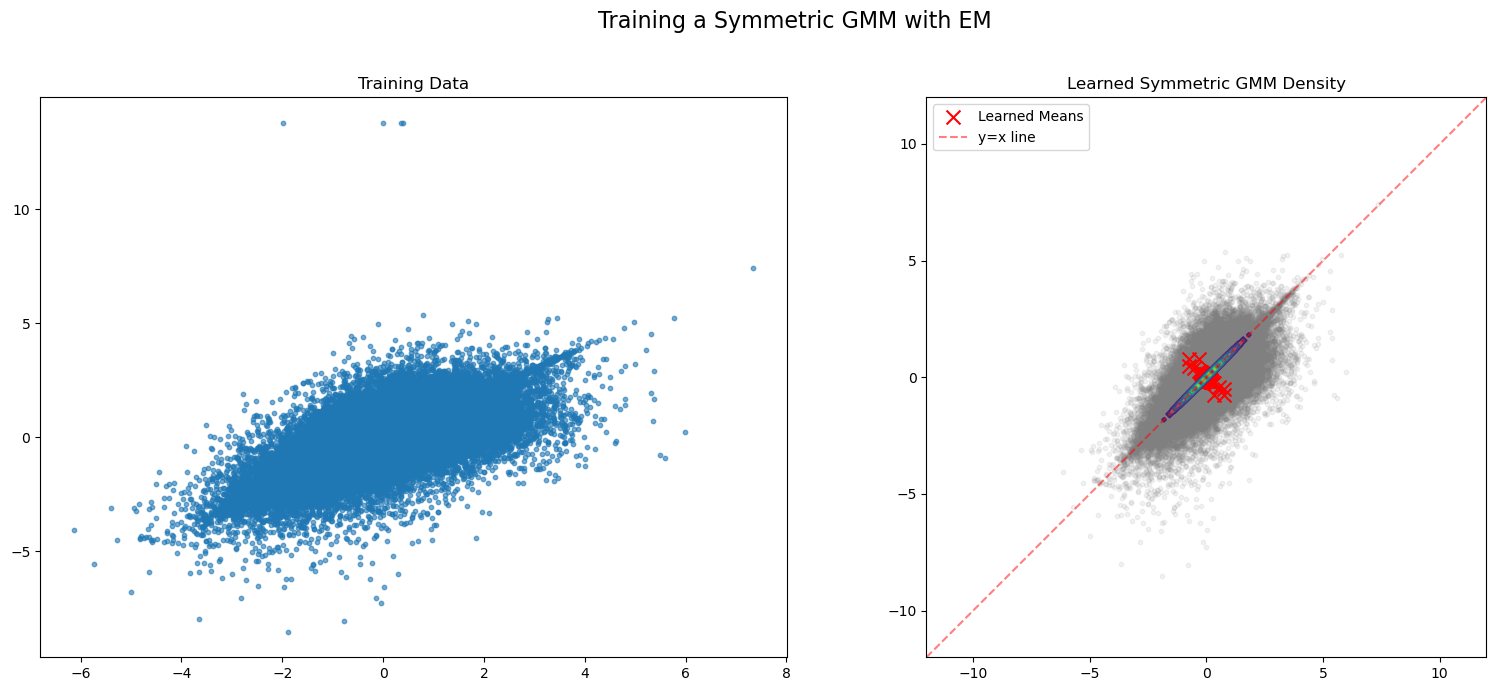

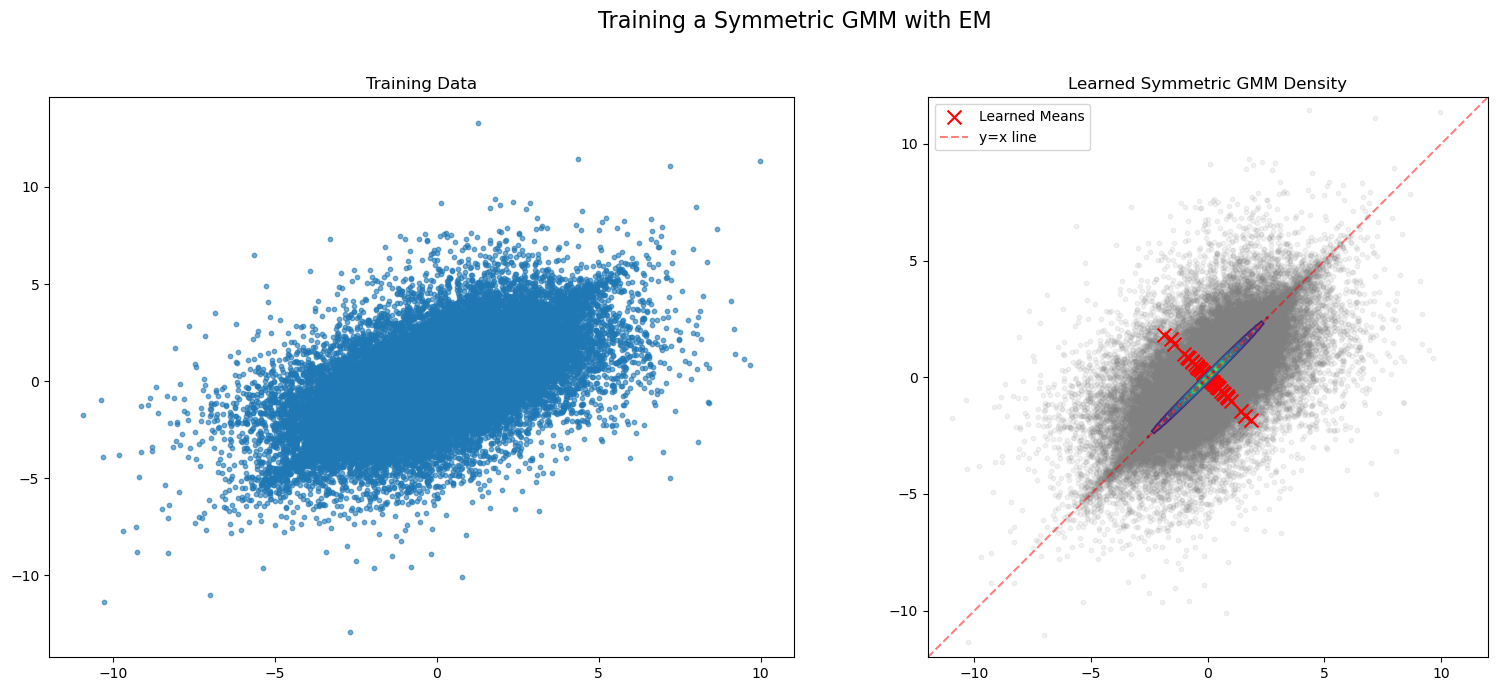

In [15]:
# 1. Generate synthetic data from a known symmetric GMM
key = jax.random.PRNGKey(42)

# 2. Train a new SymmetricGMM on this data
gmm_eps_t = SymmetricGMM()
gmm_eps_rA = SymmetricGMM()
key, subkey = jax.random.split(key)

data_eps_t = jnp.vstack([X_train[:, 1], Y_train[:, 0]]).T
data_eps_rA = jnp.vstack([X_train[:, 2], Y_train[:, 1]]).T

# The user specifies the number of BASE modes they want to find
gmm_eps_t.fit(data_eps_t, n_base_components=40, n_iterations=50, key=subkey)
gmm_eps_rA.fit(data_eps_rA, n_base_components=40, n_iterations=50, key=subkey)

# 3. Visualize the results
fig = plt.figure(figsize=(16, 7))

# Plot training data
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Training Data")
ax1.scatter(data_eps_t[:, 0], data_eps_t[:, 1], s=10, alpha=0.6)

# Plot learned distribution
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("Learned Symmetric GMM Density")
ax2.scatter(data_eps_t[:, 0], data_eps_t[:, 1], s=10, alpha=0.1, color='gray') # Show data in background

# Create a grid for contour plot
x = jnp.linspace(-12, 12, 100)
y = jnp.linspace(-12, 12, 100)
X, Y = jnp.meshgrid(x, y)
grid_points = jnp.dstack((X, Y)).reshape(-1, 2)

# Calculate probability density on the grid
log_probs = jax.vmap(
    lambda mu, cov, w: jnp.log(w) + multivariate_normal.logpdf(grid_points, mu, cov)
)(gmm_eps_t.means, gmm_eps_t.covariances, gmm_eps_t.weights)

total_log_prob = jax.scipy.special.logsumexp(log_probs, axis=0)
Z = jnp.exp(total_log_prob).reshape(100, 100)

# Plot contours and means
ax2.contour(X, Y, Z, levels=10, cmap='viridis')
ax2.scatter(gmm_eps_t.means[:, 0], gmm_eps_t.means[:, 1], marker='x', color='red', s=100, label='Learned Means')
ax2.plot([-12, 12], [-12, 12], 'r--', label='y=x line', alpha=0.5)

ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim(-12, 12)
ax2.set_ylim(-12, 12)
ax2.legend()

plt.suptitle("Training a Symmetric GMM with EM", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Visualize the results
fig = plt.figure(figsize=(16, 7))

# Plot training data
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Training Data")
ax1.scatter(data_eps_rA[:, 0], data_eps_rA[:, 1], s=10, alpha=0.6)

# Plot learned distribution
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("Learned Symmetric GMM Density")
ax2.scatter(data_eps_rA[:, 0], data_eps_rA[:, 1], s=10, alpha=0.1, color='gray') # Show data in background

# Create a grid for contour plot
x = jnp.linspace(-12, 12, 100)
y = jnp.linspace(-12, 12, 100)
X, Y = jnp.meshgrid(x, y)
grid_points = jnp.dstack((X, Y)).reshape(-1, 2)

# Calculate probability density on the grid
log_probs = jax.vmap(
    lambda mu, cov, w: jnp.log(w) + multivariate_normal.logpdf(grid_points, mu, cov)
)(gmm_eps_rA.means, gmm_eps_rA.covariances, gmm_eps_rA.weights)

total_log_prob = jax.scipy.special.logsumexp(log_probs, axis=0)
Z = jnp.exp(total_log_prob).reshape(100, 100)

# Plot contours and means
ax2.contour(X, Y, Z, levels=10, cmap='viridis')
ax2.scatter(gmm_eps_rA.means[:, 0], gmm_eps_rA.means[:, 1], marker='x', color='red', s=100, label='Learned Means')
ax2.plot([-12, 12], [-12, 12], 'r--', label='y=x line', alpha=0.5)

ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim(-12, 12)
ax2.set_ylim(-12, 12)
ax2.legend()

plt.suptitle("Training a Symmetric GMM with EM", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

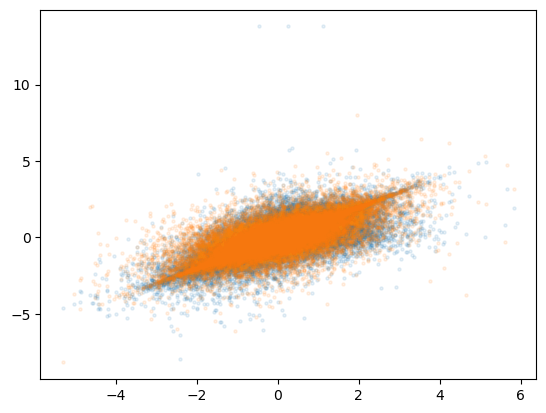

In [16]:
y_test_sample_t = gmm_eps_t.conditional_sample(key, X_test[:, 1])

plt.scatter(X_test[:, 1], Y_test[:, 0], s=5, alpha=0.1, label='True Data')
plt.scatter(X_test[:, 1], y_test_sample_t, s=5, alpha=0.1, label='True Data')

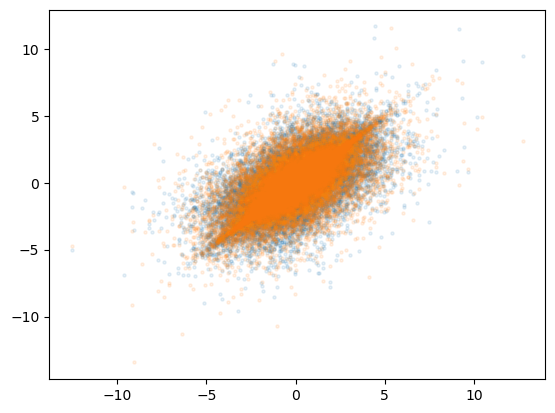

In [17]:
y_test_sample_rA = gmm_eps_rA.conditional_sample(key, X_test[:, 2])

plt.scatter(X_test[:, 2], Y_test[:, 1], s=5, alpha=0.1, label='True Data')
plt.scatter(X_test[:, 2], y_test_sample_rA, s=5, alpha=0.1, label='True Data')

## analytical based expected value: quicker and precise

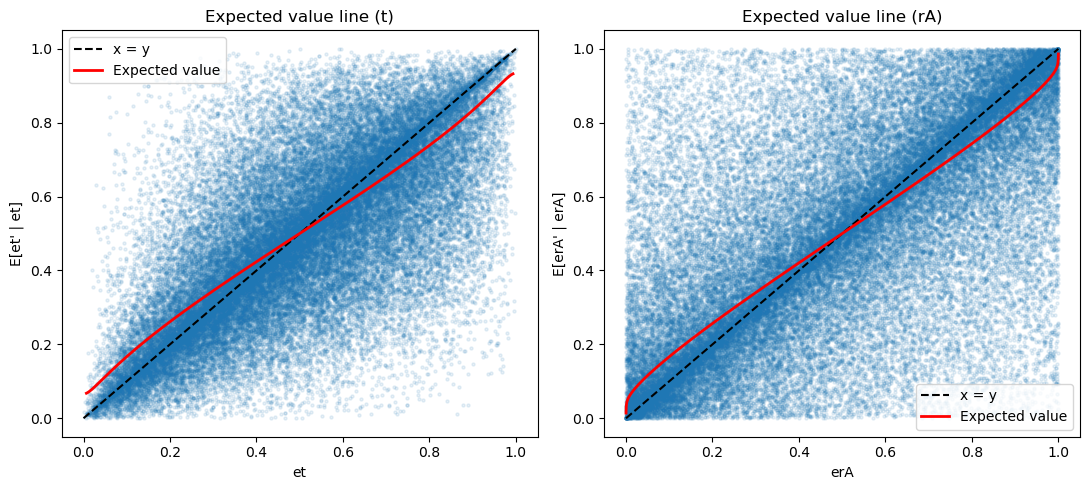

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define linear range for input (logit space)
n_points = 200
n_samples = 1

x_grid_t = np.linspace(-5, 5, n_points)
x_grid_rA = np.linspace(-10, 10, n_points)

# --- For et ---
# Repeat x_grid_t for each sample
x_input_t = np.tile(x_grid_t, n_samples)

# Sample all at once
y_samples_t = gmm_eps_t.conditional_expected_value(x_input_t)

# Reshape back to (n_points, n_samples)
y_samples_t = y_samples_t.reshape(n_samples, n_points).T

# Compute expected value
expected_t = y_samples_t.mean(axis=1)

# --- For erA ---
x_input_rA = np.tile(x_grid_rA, n_samples)
y_samples_rA = gmm_eps_rA.conditional_expected_value(x_input_rA)
y_samples_rA = y_samples_rA.reshape(n_samples, n_points).T
expected_rA = y_samples_rA.mean(axis=1)

# --- Plot ---
plt.figure(figsize=[11,5])

# et plot
plt.subplot(1,2,1)
plt.xlabel("et")
plt.ylabel("E[et' | et]")
plt.title("Expected value line (t)")
plt.scatter(inv_logit(X_train[:, 1]), inv_logit(Y_train[:, 0]), s=5, alpha=0.1)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label="x = y")
plt.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='red', lw=2, label="Expected value")
plt.legend()

# erA plot
plt.subplot(1,2,2)
plt.xlabel("erA")
plt.ylabel("E[erA' | erA]")
plt.title("Expected value line (rA)")
plt.scatter(inv_logit(X_train[:, 2]), inv_logit(Y_train[:, 1]), s=5, alpha=0.1)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label="x = y")
plt.plot(inv_logit(x_grid_rA), inv_logit(expected_rA), color='red', lw=2, label="Expected value")
plt.legend()

plt.tight_layout()
plt.show()

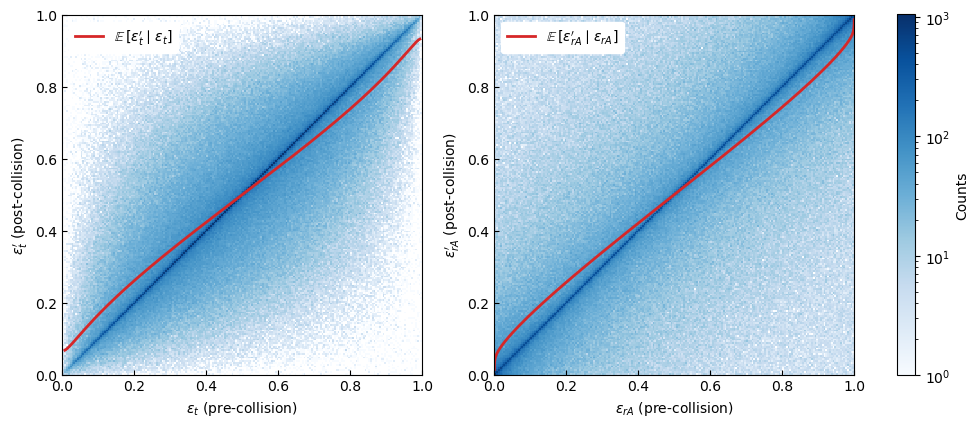

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import beta
import jax

# --- Helper functions ---
def logit(p):
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

# --- Input setup ---
n_points = 1000
n_samples = 1_000_000
bins = 200
rng = np.random.default_rng(43)

# Beta inputs
x_samples_t = beta.rvs(2, 2, size=n_samples, random_state=rng)
x_input_t = logit(x_samples_t)
x_samples_rA = beta.rvs(1, 1, size=n_samples, random_state=rng)
x_input_rA = logit(x_samples_rA)

# --- Pass through both GMMs ---
key = jax.random.PRNGKey(0)
y_samples_t = gmm_eps_t.conditional_sample(key, x_input_t)
y_samples_rA = gmm_eps_rA.conditional_sample(key, x_input_rA)

# --- Expected value lines ---
x_grid_t = np.linspace(-5, 5, n_points)
x_grid_rA = np.linspace(-10, 10, n_points)
expected_t = gmm_eps_t.conditional_expected_value(x_grid_t)
expected_rA = gmm_eps_rA.conditional_expected_value(x_grid_rA)

# --- Transform back to probability space ---
x_plot_t = inv_logit(x_input_t)
y_plot_t = inv_logit(y_samples_t)
x_plot_rA = inv_logit(x_input_rA)
y_plot_rA = inv_logit(y_samples_rA)

# --- Compute common color scale ---
# Use small sample histograms just to find global vmin/vmax
h_t, _, _ = np.histogram2d(x_plot_t, y_plot_t, bins=bins)
h_rA, _, _ = np.histogram2d(x_plot_rA, y_plot_rA, bins=bins)
vmin = max(1, min(h_t[h_t > 0].min(), h_rA[h_rA > 0].min()))  # avoid 0 for LogNorm
vmax = max(h_t.max(), h_rA.max())

# Define linear range for input (logit space)
n_points = 200
n_samples = 1

x_grid_t = np.linspace(-5, 5, n_points)
x_grid_rA = np.linspace(-10, 10, n_points)

# --- For et ---
# Repeat x_grid_t for each sample
x_input_t = np.tile(x_grid_t, n_samples)

# Sample all at once
y_samples_t = gmm_eps_t.conditional_expected_value(x_input_t)

# Reshape back to (n_points, n_samples)
y_samples_t = y_samples_t.reshape(n_samples, n_points).T

# Compute expected value
expected_t = y_samples_t.mean(axis=1)

# --- For erA ---
x_input_rA = np.tile(x_grid_rA, n_samples)
y_samples_rA = gmm_eps_rA.conditional_expected_value(x_input_rA)
y_samples_rA = y_samples_rA.reshape(n_samples, n_points).T
expected_rA = y_samples_rA.mean(axis=1)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ---- eps_t ----
ax = axes[0]
h = ax.hist2d(
    x_plot_t,
    y_plot_t,
    bins=bins,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap='Blues'
)
# ax.plot([0, 1], [0, 1], color='black', linestyle='--', lw=1.5, label="x = y")
ax.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='C3', lw=2, label=r"$\mathbb{E}\,[\varepsilon_t' \mid \varepsilon_t]$")
ax.set_xlabel(r"$\varepsilon_{t}$ (pre-collision)")
ax.set_ylabel(r"$\varepsilon_{t}'$ (post-collision)")
ax.tick_params(direction='in')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(facecolor='white', framealpha=1.0, loc='upper left', edgecolor='white')

# ---- eps_rA ----
ax = axes[1]
h2 = ax.hist2d(
    x_plot_rA,
    y_plot_rA,
    bins=bins,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap='Blues'
)
# ax.plot([0, 1], [0, 1], color='black', linestyle='--', lw=1.5, label="x = y")
ax.plot(inv_logit(x_grid_rA), inv_logit(expected_rA), color='C3', lw=2, label=r"$\mathbb{E}\,[\varepsilon_{rA}' \mid \varepsilon_{rA}]$")
ax.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax.set_ylabel(r"$\varepsilon_{rA}'$ (post-collision)")
ax.tick_params(direction='in')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(facecolor='white', framealpha=1.0, loc='upper left', edgecolor='white')

# --- Shared colorbar ---
fig.colorbar(h2[3], ax=axes, orientation='vertical', fraction=0.0212, label="Counts")

plt.show()

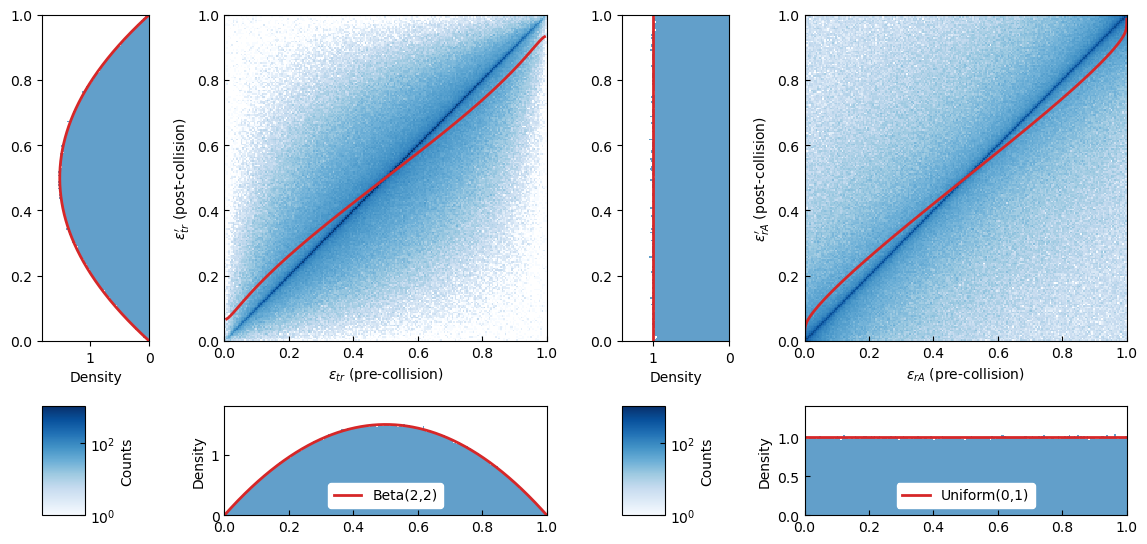

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy.stats import beta, uniform

# --- Helper functions ---
def logit(p):
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

# --- Input setup ---
n_points = 1000
n_samples = 1_000_000
bins = 200
rng = np.random.default_rng(43)

# Beta inputs
x_samples_t = beta.rvs(2, 2, size=n_samples, random_state=rng)
x_input_t = logit(x_samples_t)
x_samples_rA = beta.rvs(1, 1, size=n_samples, random_state=rng)
x_input_rA = logit(x_samples_rA)

# --- Pass through both GMMs ---
key = jax.random.PRNGKey(0)
y_samples_t = gmm_eps_t.conditional_sample(key, x_input_t)
y_samples_rA = gmm_eps_rA.conditional_sample(key, x_input_rA)

# --- Expected value lines ---
x_grid_t = np.linspace(-5, 5, n_points)
x_grid_rA = np.linspace(-10, 10, n_points)
expected_t = gmm_eps_t.conditional_expected_value(x_grid_t)
expected_rA = gmm_eps_rA.conditional_expected_value(x_grid_rA)

# --- Transform back to probability space ---
x_tr = inv_logit(x_input_t)
y_tr = inv_logit(y_samples_t)
x_rot = inv_logit(x_input_rA)
y_rot = inv_logit(y_samples_rA)

xs = np.linspace(0, 1, 1000)

# Figure + GridSpec:
fig = plt.figure(figsize=(14, 6.5))
# Make thin margin columns small and 2D columns large
grid = fig.add_gridspec(2, 4,
                        width_ratios=[1, 3.0, 1, 3.0],
                        height_ratios=[3.0, 1],
                        hspace=0.3, wspace=0.35)


# ---- create the 2D panels first so we can share y with the left marginal ----
ax2 = fig.add_subplot(grid[0, 1])   # top-row, 2D translational
h1 = ax2.hist2d(x_tr, y_tr, bins=200, norm=LogNorm(), cmap='Blues')
ax2.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='C3', lw=2, label="Expected value")
ax2.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax2.set_ylabel(r"$\varepsilon_{tr}'$ (post-collision)")
ax2.tick_params(direction='in')
#ax2.set_box_aspect(1)   # keep square
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

ax4 = fig.add_subplot(grid[0, 3])   # top-row, 2D rotational
h2 = ax4.hist2d(x_rot, y_rot, bins=200, norm=LogNorm(), cmap='Blues')
ax4.plot(inv_logit(x_grid_rA), inv_logit(expected_rA), color='C3', lw=2, label="Expected value")
ax4.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax4.set_ylabel(r"$\varepsilon_{rA}'$ (post-collision)")
ax4.tick_params(direction='in')
#ax4.set_box_aspect(1)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

# colorbars (adjust fraction/pad so they don't shrink the axes)

# === COLORBARS in bottom row (cols 0 and 2, thinner) ===
ax_cb1 = fig.add_subplot(grid[1, 0])
ax_cb2 = fig.add_subplot(grid[1, 2])

# Create horizontal colorbars with thinner height
cb1 = fig.colorbar(h1[3], cax=ax_cb1, orientation='vertical')
cb2 = fig.colorbar(h2[3], cax=ax_cb2, orientation='vertical')

# Make the colorbars thinner by reducing their width
for cb_ax in [cb1.ax, cb2.ax]:
    pos = cb_ax.get_position()
    # pos = [x0, y0, width, height]
    cb_ax.set_position([pos.x0, pos.y0, 0.4*pos.width, pos.height])

cb1.set_label("Counts")
cb2.set_label("Counts")

# Make ticks point inward
for cb_ax in [ax_cb1, ax_cb2]:
    cb_ax.tick_params(direction='in')


# ---- Top-row thin marginals (horizontal, share y with respective 2D axes) ----
# Left top: post-collision translational (horizontal), share y with ax2
ax1 = fig.add_subplot(grid[0, 0], sharey=ax2)
# horizontal histogram along y; orientation='horizontal'
ax1.hist(y_tr, bins=200, density=True, alpha=0.7, orientation='horizontal')
# plot PDF: for horizontal orientation plot pdf on x vs xs on y
ax1.plot(beta.pdf(xs, 2, 2), xs, '-', color="C3", lw=2, label='Beta(2,2)')
ax1.set_ylim(0, 1)
ax1.set_xlim(0, 1.8)
# invert x so bars extend *towards* the 2D plot
ax1.invert_xaxis()
ax1.set_xlabel("Density")


# Right top: post-collision rotational (horizontal), share y with ax4
ax3 = fig.add_subplot(grid[0, 2], sharey=ax4)
ax3.hist(y_rot, bins=200, density=True, alpha=0.7, orientation='horizontal')
ax3.plot(uniform.pdf(xs, 0, 1), xs, '-', color="C3", lw=2, label='Uniform(0,1)')
ax3.set_ylim(0, 1)
ax3.set_xlim(0, 1.4)
ax3.invert_xaxis()
ax3.set_xlabel("Density")


# ---- Bottom row: thin 1D histograms (pre-collision), keep them horizontal? vertically oriented is fine ----
# Column 2 (bottom middle-left): pre-collision translational
ax5 = fig.add_subplot(grid[1, 1], sharex=ax2)
ax5.hist(x_tr, bins=200, density=True, alpha=0.7)
ax5.plot(xs, beta.pdf(xs, 2, 2), '-', color="C3", lw=2, label="Beta(2,2)")
# ax5.plot(beta.pdf(xs, 2, 2)*-1, xs, '-', color="orange", lw=2, label='Beta(2,2)')
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1.8)
# ax5.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax5.set_ylabel("Density")
ax5.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax5.tick_params(direction='in')

# Column 4 (bottom right): pre-collision rotational
ax6 = fig.add_subplot(grid[1, 3], sharex=ax2)
ax6.hist(x_rot, bins=200, density=True, alpha=0.7)
ax6.plot(xs, uniform.pdf(xs, 0, 1), '-', color="C3", lw=2, label="Uniform(0,1)")
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1.4)
# ax6.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax6.set_ylabel("Density")
ax6.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax6.tick_params(direction='in')

plt.show()

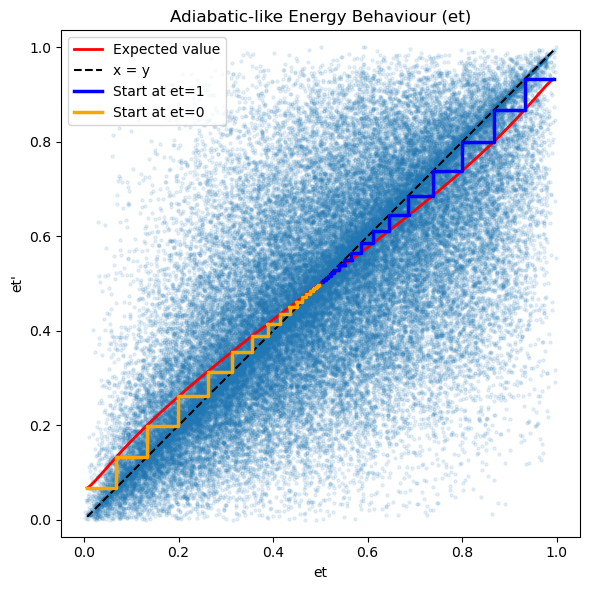

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare plotting variables
x_vals = inv_logit(x_grid_t)
y_exp = inv_logit(expected_t)
y_identity = x_vals

# Helper to find nearest value on curve
def find_nearest_index(array, value):
    return np.argmin(np.abs(array - value))

def make_bounce_path(x_vals, y_exp, start_x, n_steps=5):
    """
    Create a 'bouncing' step path that alternates horizontally to x=y line 
    and vertically to the expected curve.
    """
    path_x = []
    path_y = []

    # Start at expected line
    i = find_nearest_index(x_vals, start_x)
    x, y = x_vals[i], y_exp[i]

    path_x.append(x)
    path_y.append(y)

    going_to_identity = True

    for _ in range(n_steps):
        if going_to_identity:
            # Horizontal step to x=y line
            y_target = y
            x_target = y_target  # since y=x on the identity line
        else:
            # Vertical step back to expected line
            i_target = find_nearest_index(x_vals, x)
            x_target = x_vals[i_target]
            y_target = y_exp[i_target]

        # Add this segment
        path_x.extend([path_x[-1], x_target])
        path_y.extend([path_y[-1], y_target])

        # Update current point and toggle direction
        x, y = x_target, y_target
        going_to_identity = not going_to_identity

    return path_x, path_y


# Create the two bounce paths
x_step_pos, y_step_pos = make_bounce_path(x_vals, y_exp, start_x=1, n_steps=50)
x_step_neg, y_step_neg = make_bounce_path(x_vals, y_exp, start_x=0, n_steps=50)

# --- Plot ---
plt.figure(figsize=[6,6])
plt.xlabel("et")
plt.ylabel("et'")
plt.title("Adiabatic-like Energy Behaviour (et)")

# Scatter for reference
plt.scatter(inv_logit(X_train[:, 1]), inv_logit(Y_train[:, 0]), s=5, alpha=0.1)

# Expected and identity lines
plt.plot(x_vals, y_exp, color='red', lw=2, label="Expected value")
plt.plot(x_vals, y_identity, color='black', linestyle='--', lw=1.5, label="x = y")

# Step/bounce paths
plt.plot(x_step_pos, y_step_pos, color='blue', lw=2.5, drawstyle='steps-pre', label="Start at et=1")
plt.plot(x_step_neg, y_step_neg, color='orange', lw=2.5, drawstyle='steps-pre', label="Start at et=0")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import beta, uniform

n_points = 1000

xs = np.linspace(0.005, 0.995, n_points)
pdf = beta.pdf(xs, 2, 2)  # Beta(2,2)

expected_value = np.sum(inv_logit(expected_t) * pdf) / np.sum(pdf) 

print(expected_value)

0.5000000003276468


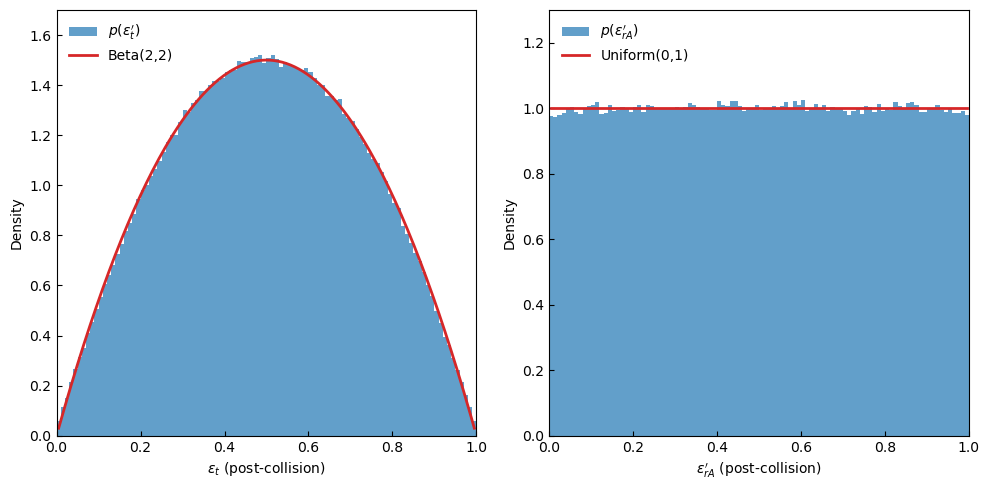

In [23]:
# --- Input setup ---
n_points = 200
xs = np.linspace(0.005, 0.995, n_points)

# Sample x according to Beta(2,2)
rng = np.random.default_rng(43)
x_samples = beta.rvs(2, 2, size=1_000_000, random_state=rng)

# Transform to logit space if needed by your GMM
x_input = logit(x_samples)

# --- Pass through GMM ---
# (Assuming gmm_eps_t has a method `conditional_sample`)
key = jax.random.PRNGKey(0)
y_samples = gmm_eps_t.conditional_sample(key, x_input)

# --- Compare input vs. output distributions ---
plt.figure(figsize=(10, 5))
# Input distribution: Beta(2,2)
pdf = beta.pdf(xs, 2, 2)

plt.subplot(1, 2, 1)
plt.hist(inv_logit(y_samples), bins=100, density=True, alpha=0.7, label=r"$p(\varepsilon_{t}')$")
plt.plot(xs, pdf, '-', color='C3', lw=2, label='Beta(2,2)')
plt.xlabel(r"$\varepsilon_{t}$ (post-collision)")
plt.ylabel("Density")
plt.legend(facecolor='white', framealpha=0, loc='upper left', edgecolor='white')
plt.ylim(0, 1.7)
plt.xlim(0, 1)
plt.tick_params(direction='in')

# Sample x according to Beta(2,2)
rng = np.random.default_rng(43)
x_samples = beta.rvs(1, 1, size=1_000_000, random_state=rng)

# Transform to logit space if needed by your GMM
x_input = logit(x_samples)

# --- Pass through GMM ---
# (Assuming gmm_eps_t has a method `conditional_sample`)
key = jax.random.PRNGKey(0)
y_samples = gmm_eps_rA.conditional_sample(key, x_input)

# Input distribution: Beta(1,1)
pdf = beta.pdf(xs, 1, 1)
plt.subplot(1, 2, 2)
plt.hist(inv_logit(y_samples), bins=100, density=True, alpha=0.7, label=r"$p(\varepsilon_{rA}')$")
plt.plot(xs, pdf, '-', color='C3', lw=2, label='Uniform(0,1)')
plt.xlabel(r"$\varepsilon_{rA}'$ (post-collision)")
plt.ylabel("Density")
plt.legend(facecolor='white', framealpha=0, loc='upper left', edgecolor='white')
plt.ylim(0, 1.3)
plt.xlim(0, 1)
plt.tick_params(direction='in')

plt.tight_layout()
plt.show()

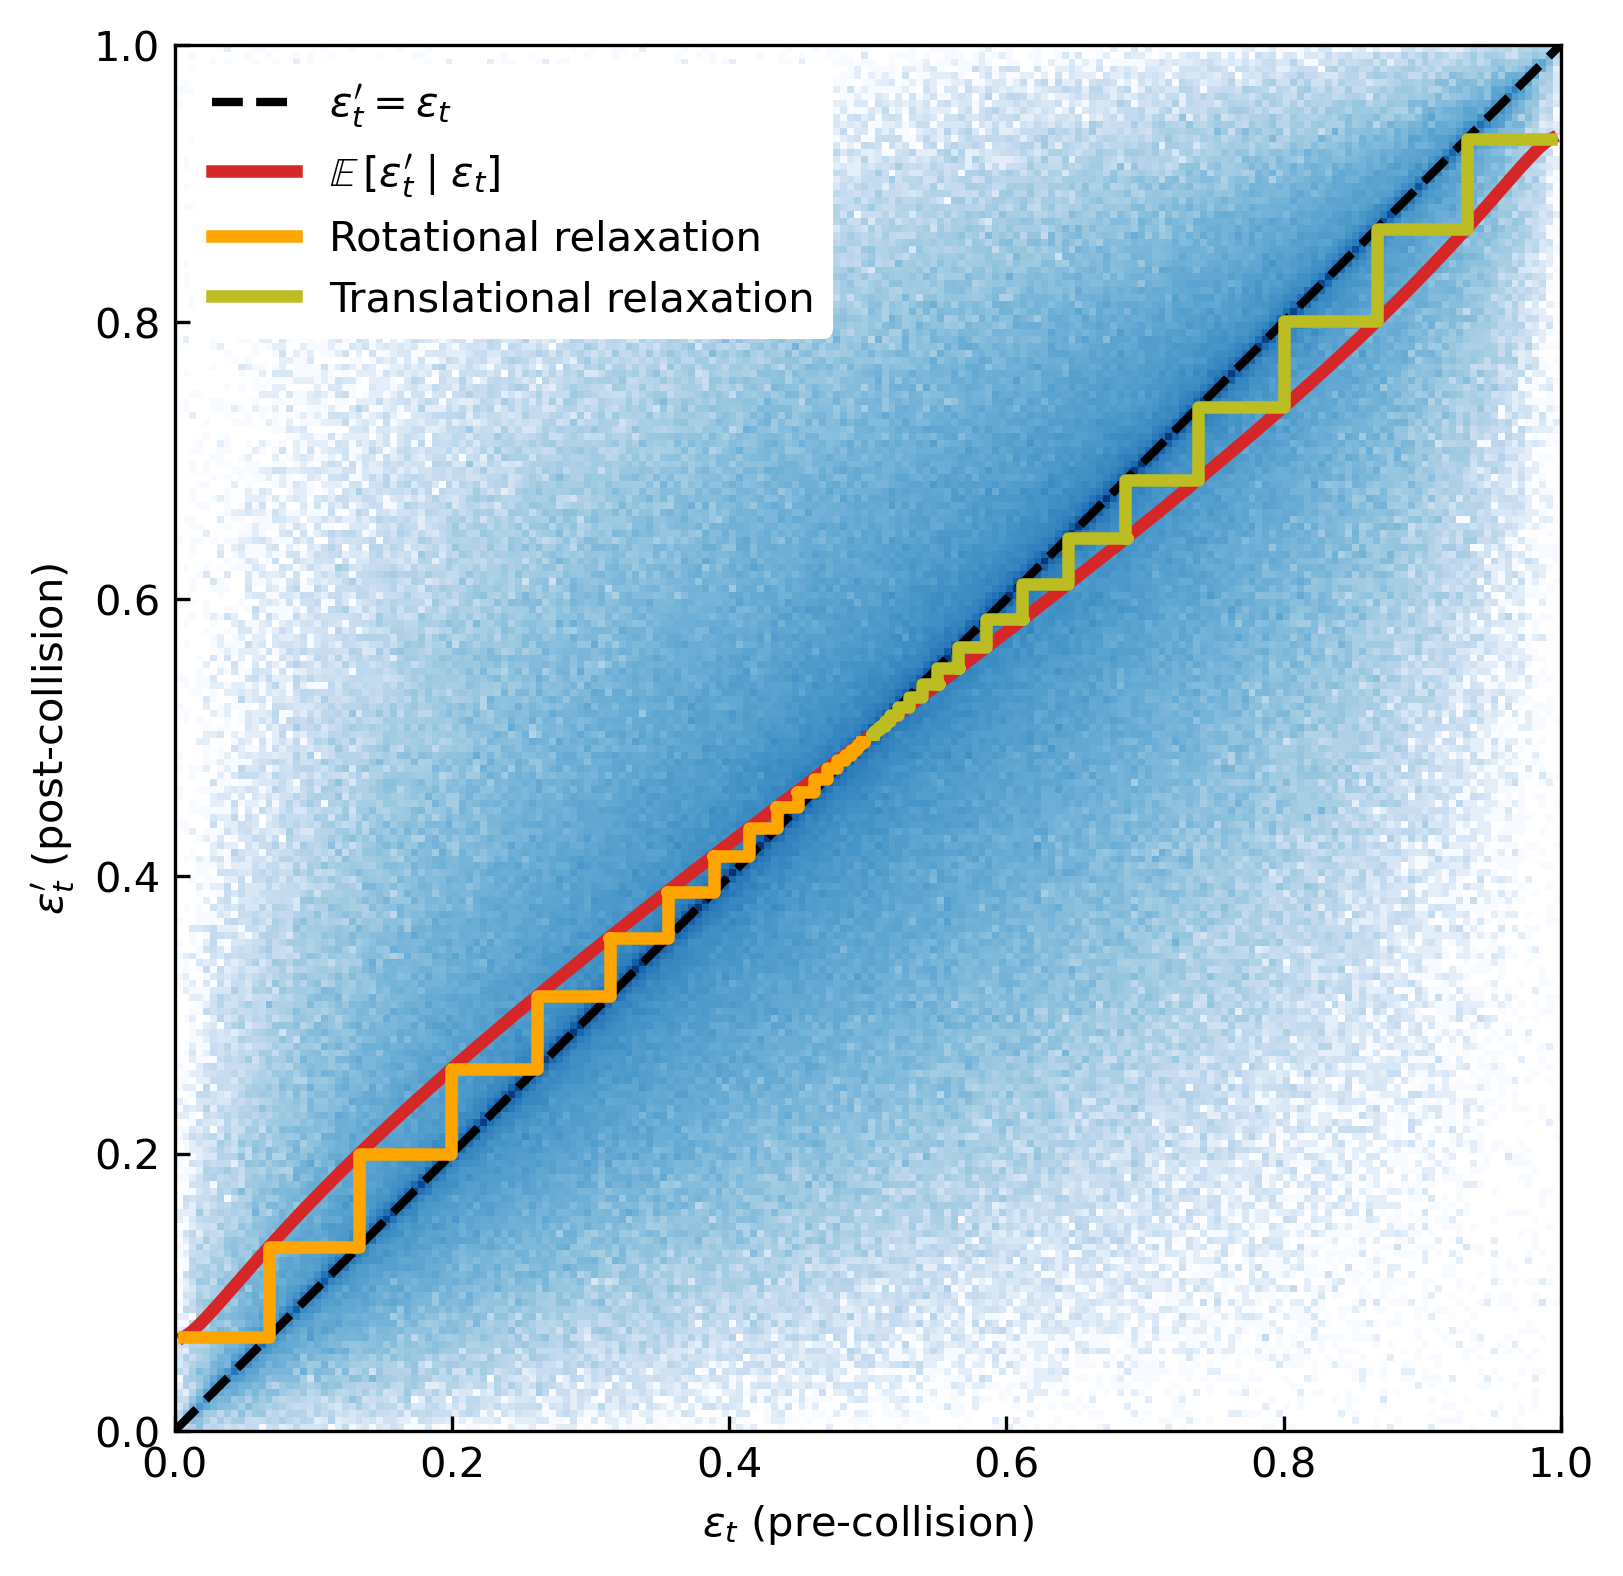

In [24]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
# ---- eps_t ----
h = ax.hist2d(
    x_plot_t,
    y_plot_t,
    bins=bins,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap='Blues',
)

# 3. Add labels and a color bar
ax.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, alpha=1, label=r"$\varepsilon_t' = \varepsilon_t$")
ax.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='C3', lw=3,  label=r"$\mathbb{E}\,[\varepsilon_t' \mid \varepsilon_t]$")
ax.plot(x_step_neg, y_step_neg, color='orange', lw=3, drawstyle='steps-pre', label="Rotational relaxation")
ax.plot(x_step_pos, y_step_pos, color='C8', lw=3, drawstyle='steps-pre', label="Translational relaxation")
plt.xlim(0, 1)
plt.ylim(0, 1)
ax.tick_params(direction='in')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r"$\varepsilon_{t}$ (pre-collision)")
ax.set_ylabel(r"$\varepsilon_{t}'$ (post-collision)")
# fig.colorbar(h[3], ax=ax, label="Counts")
plt.legend(facecolor='white', framealpha=1, loc='upper left', edgecolor='white')

# 4. Display the plot
plt.show()

In [25]:
def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_logit(z):
    return jnp.clip(1.0 / (1.0 + jnp.exp(-z)), 1e-12, 1 - 1e-12)

def gmm_sample_conserve(X, Ec, n_samples=1, key=random.PRNGKey(0)):
    """
    Sample post-collision energy fractions from MDN while conserving total energy.
    Returns energies Etr', Er1', Er2' such that sum = Ec always.
    """

    key1, key2 = jax.random.split(key)
    y_test_sample_t = gmm_eps_t.conditional_sample(key1, X[:, 1])
    y_test_sample_rA = gmm_eps_rA.conditional_sample(key2, X[:, 2])
    
    eps_t_p = inv_logit(y_test_sample_t)[:, None]   # Shape: (N, n_samples)
    eps_rA_p = inv_logit(y_test_sample_rA)[:, None] # Shape: (N, n_samples)
    

    Ec_exp = Ec[:, None]  # Shape (N, 1) to allow broadcasting

    # 1. Calculate post-collision translational energy
    Etr_p = eps_t_p * Ec_exp

    # 2. Calculate total post-collision rotational energy
    Erot_p_total = (1.0 - eps_t_p) * Ec_exp

    # 3. Split total rotational energy between molecules A and B
    Er1_p = eps_rA_p * Erot_p_total
    Er2_p = (1.0 - eps_rA_p) * Erot_p_total
    
    return Etr_p, Er1_p, Er2_p


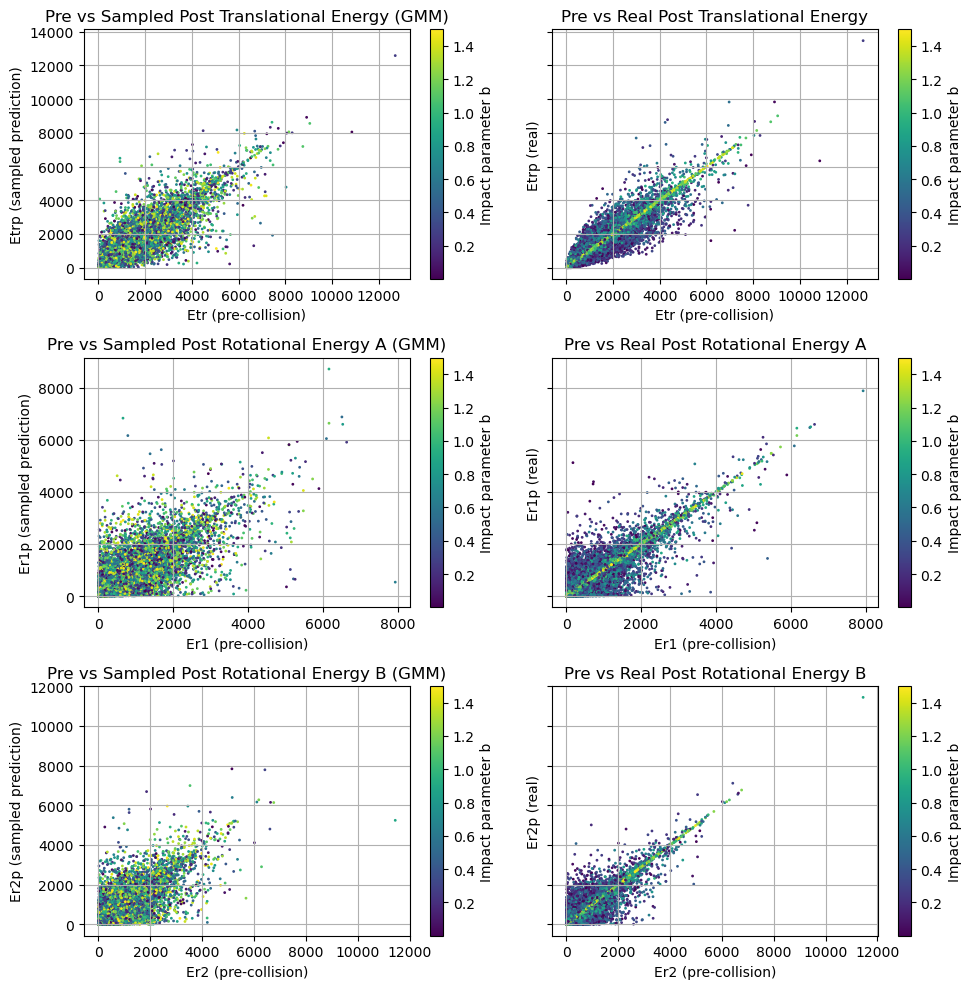

In [26]:

Etrp_samp_test, Er1p_samp_test, Er2p_samp_test = gmm_sample_conserve(X_test, Ec_test, n_samples=1, key=random.PRNGKey(1))

# Make subplots: 3 rows (Etr, Er1, Er2) × 2 cols (Pred vs Real)
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey='row',)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# --- Row 1: Translational energy ---
# Left: predicted
sc0 = axes[0, 0].scatter(data_test["Etr"], Etrp_samp_test, alpha=1, s=1, c=data_test["b"])
axes[0, 0].set_title("Pre vs Sampled Post Translational Energy (GMM)")
axes[0, 0].set_xlabel("Etr (pre-collision)")
axes[0, 0].set_ylabel("Etrp (sampled prediction)")
fig.colorbar(sc0, ax=axes[0, 0], label='Impact parameter b')
axes[0, 0].grid(True)

# Right: real
sc1 = axes[0, 1].scatter(data_test["Etr"], data_test["Etrp"], alpha=1, s=1, c=data_test["b"])
axes[0, 1].set_title("Pre vs Real Post Translational Energy")
axes[0, 1].set_xlabel("Etr (pre-collision)")
axes[0, 1].set_ylabel("Etrp (real)")
fig.colorbar(sc1, ax=axes[0, 1], label='Impact parameter b')
axes[0, 1].grid(True)

# --- Row 2: Rotational Energy A ---
sc2 = axes[1, 0].scatter(data_test["Er1"], Er1p_samp_test, alpha=1, s=1, c=data_test["b"])
axes[1, 0].set_title("Pre vs Sampled Post Rotational Energy A (GMM)")
axes[1, 0].set_xlabel("Er1 (pre-collision)")
axes[1, 0].set_ylabel("Er1p (sampled prediction)")
fig.colorbar(sc2, ax=axes[1, 0], label='Impact parameter b')
axes[1, 0].grid(True)

sc3 = axes[1, 1].scatter(data_test["Er1"], data_test["Er1p"], alpha=1, s=1, c=data_test["b"])
axes[1, 1].set_title("Pre vs Real Post Rotational Energy A")
axes[1, 1].set_xlabel("Er1 (pre-collision)")
axes[1, 1].set_ylabel("Er1p (real)")
fig.colorbar(sc3, ax=axes[1, 1], label='Impact parameter b')
axes[1, 1].grid(True)

# --- Row 3: Rotational Energy B ---
sc4 = axes[2, 0].scatter(data_test["Er2"], Er2p_samp_test, alpha=1, s=1, c=data_test["b"])
axes[2, 0].set_title("Pre vs Sampled Post Rotational Energy B (GMM)")
axes[2, 0].set_xlabel("Er2 (pre-collision)")
axes[2, 0].set_ylabel("Er2p (sampled prediction)")
fig.colorbar(sc4, ax=axes[2, 0], label='Impact parameter b')
axes[2, 0].grid(True)

sc5 = axes[2, 1].scatter(data_test["Er2"], data_test["Er2p"], alpha=1, s=1, c=data_test["b"])
axes[2, 1].set_title("Pre vs Real Post Rotational Energy B")
axes[2, 1].set_xlabel("Er2 (pre-collision)")
axes[2, 1].set_ylabel("Er2p (real)")
fig.colorbar(sc5, ax=axes[2, 1], label='Impact parameter b')
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

# DSMC - termal equilibrium

In [27]:
params= None

In [28]:
import time
from scipy.stats import maxwell

# ---------------------------
# Physical & simulation params
# ---------------------------
n_particles = 10_000        # increase for better statistics
T0 = 300.0                 # Kelvin (initial equilibrium temperature)
kB = 1.38064852e-23
m_H = 1.6738e-27
m_molecule = 2.0 * m_H     # diatomic identical masses
mu_pair = 0.5 * m_molecule  # reduced mass for identical molecules

# DSMC timestepping
dt = 1e-4
t_end = 0.1 # 0.025 or 0.1
n_steps = int(jnp.ceil(t_end / dt))

snapshot_times = [0.0, 0.013, 0.025, 0.05, 0.75, 0.100]
snapshots = []

# collision candidate batch size per timestep
n_cand = max(200, n_particles // 2)

# PRNG key (JAX)
key = jax.random.PRNGKey(1234)

# ---------------------------
# Utility (same transforms used in training)
# ---------------------------

def preprocess_X_batch_jax(Etr_batch, Er_i_batch, Er_j_batch):
    """
    Vectorized preprocessing for MDN inputs (JAX).
    Inputs arrays shape (Npairs,)
    Returns X_batch (Npairs,3), Ec_batch (Npairs,)
    """
    Ec = Etr_batch + Er_i_batch + Er_j_batch
    E_rot_total = Er_i_batch + Er_j_batch
    eps_t = Etr_batch / (Ec+1e-12)
    eps_r_A = Er_i_batch / (E_rot_total+1e-12)
    # use jnp.log and logit_jnp
    X1 = jnp.log(Ec+1e-12)
    X2 = logit(eps_t)
    X3 = logit(eps_r_A)
    X = jnp.stack([X1, X2, X3], axis=1)
    return X.astype(jnp.float32), Ec

# ---------------------------
# Initialize particles (thermal equilibrium)
# Keep only total rotational energy Er (sum of two mode energies)
# ---------------------------
key, sk = jax.random.split(key)
v_tr = jax.random.normal(sk, (n_particles, 3)) * jnp.sqrt(kB * T0 / m_molecule) # 167

# sample Er_total as Gamma(k=1, scale=kB*T0) using JAX
key, sk = jax.random.split(key)
Er = jax.random.gamma(sk, 1.0, (n_particles,)) * (kB * T0)  # total rotational energy per particle

# convert to numpy for some plotting functions that expect numpy later
v_tr = jnp.array(v_tr)
Er = jnp.array(Er)

# ---------------------------
# Helper: generate disjoint candidate pairs & accept by relative speed (JAX)
# ---------------------------
def select_disjoint_candidates_and_accept(key, v_tr, n_cand):
    """
    Produce disjoint candidate pairs by random permutation:
      - permute indices, take first 2*n_cand indices, reshape to (n_cand,2)
    Accept each pair with probability g/gmax (relative speed weighting).
    Returns:
      key, i_acc (array), j_acc (array), g_acc (array), gmax (scalar)
    """
    N = v_tr.shape[0]
    key, kperm, kune = jax.random.split(key, 3)
    perm = jax.random.permutation(kperm, N)
    # if 2*n_cand > N, reduce n_cand to floor(N/2)
    max_pairs = N // 2
    n_cand_eff = jnp.minimum(n_cand, max_pairs)
    idx2 = perm[:2 * n_cand_eff]
    pairs = idx2.reshape((n_cand_eff, 2))
    i_cand = pairs[:, 0]
    j_cand = pairs[:, 1]
    v_rel = v_tr[i_cand] - v_tr[j_cand]
    g = jnp.linalg.norm(v_rel, axis=1)
    gmax = jnp.maximum(g.max(), 1e-12)
    p = g / gmax
    u = jax.random.uniform(kune, shape=(n_cand_eff,))
    accept_mask = u < p
    i_acc = i_cand[accept_mask]
    j_acc = j_cand[accept_mask]
    g_acc = g[accept_mask]
    return key, i_acc, j_acc, g_acc, gmax

# ---------------------------
# Batch collision processing (JAX vectorized)
# ---------------------------
@jax.jit
def process_pairs_batch_jax(params, key, v_i_arr, v_j_arr, Er_i_arr, Er_j_arr):
    """
    Vectorized processing of accepted disjoint pairs in JAX.
    Inputs: arrays (Npairs, ...) as jnp arrays.
    Returns: v_i_new, v_j_new, Er_i_post, Er_j_post, key
    """
    n_pairs = v_i_arr.shape[0]
    # If zero pairs, return empty arrays quickly
    def zero_return():
        return (jnp.zeros((0, 3)), jnp.zeros((0, 3)), jnp.zeros((0,)), jnp.zeros((0,)), key)

    if n_pairs == 0:
        return zero_return()

    # 1) Compute pair translational energy (relative speed)
    v_rel = v_i_arr - v_j_arr  # (n_pairs,3)
    g2 = jnp.sum(v_rel**2, axis=1)  # (n_pairs,)
    Etr_pair = 0.5 * mu_pair * g2  # (n_pairs,)

    # 2) Preprocess X batch & Ec batch for MDN
    X_batch, Ec_batch = preprocess_X_batch_jax(Etr_pair/kB, Er_i_arr/kB, Er_j_arr/kB)  # shapes (n_pairs,3), (n_pairs,)

    # 3) Call MDN once for whole batch
    # Provide per-batch key for MDN sampling:
    key, kmdn = jax.random.split(key)
    # Etrp_batch, Er_i_post_batch, Er_j_post_batch = mdn_sample_conserve(params, X_batch, Ec_batch, n_samples=1, key=kmdn)
    Etrp_batch, Er_i_post_batch, Er_j_post_batch = gmm_sample_conserve(X_batch, Ec_batch, n_samples=1, key=kmdn)
    # ensure shape (n_pairs,) for each
    Etrp_batch = jnp.squeeze(jnp.array(Etrp_batch)).reshape(-1)*kB
    Er_i_post_batch = jnp.squeeze(jnp.array(Er_i_post_batch)).reshape(-1)*kB
    Er_j_post_batch = jnp.squeeze(jnp.array(Er_j_post_batch)).reshape(-1)*kB

    # jax.debug.print("Etrp_batch: {eb}", eb=(Etr_pair/kB).mean())

    # 4) Reconstruct new velocities:
    # sample isotropic directions via two uniforms per pair
    key, kunif = jax.random.split(key)
    u = jax.random.uniform(kunif, (n_pairs, 2))
    u1 = u[:, 0]; u2 = u[:, 1]
    theta = 2.0 * jnp.pi * u1
    phi = jnp.arccos(2.0 * u2 - 1.0)
    sinphi = jnp.sin(phi)
    dir_new = jnp.stack([sinphi * jnp.cos(theta), sinphi * jnp.sin(theta), jnp.cos(phi)], axis=1)  # (n_pairs,3)

    # g_new and relative velocity
    g_new = jnp.sqrt(jnp.maximum(2.0 * Etrp_batch / mu_pair, 0.0))
    v_rel_new = dir_new * g_new[:, None]  # (n_pairs,3)

    v_cm = 0.5 * (v_i_arr + v_j_arr)
    v_i_new = v_cm + 0.5 * v_rel_new
    v_j_new = v_cm - 0.5 * v_rel_new

    return v_i_new, v_j_new, Er_i_post_batch, Er_j_post_batch, key

# ---------------------------
# Main DSMC loop (Python driver, heavy ops in JAX)
# ---------------------------
t0 = time.time()
times = []
Ttr_list = []
Trot_list = []

# initial temps
T_tr_init = float(jnp.mean(jnp.sum(v_tr**2, axis=1) * m_molecule / (3.0 * kB)))
T_rot_init = float(jnp.mean(Er) / (kB))
print(f"Initial T_tr = {T_tr_init:.3f} K, T_rot = {T_rot_init:.3f} K")

for step in range(n_steps + 1):
    t = step * dt
    # record temps
    T_tr = float(jnp.mean(jnp.sum(v_tr**2, axis=1) * m_molecule / (3.0 * kB)))
    T_rot = float(jnp.mean(Er) / (kB))
    times.append(t)
    Ttr_list.append(T_tr)
    Trot_list.append(T_rot)

    # Save snapshots
    if any(abs(t - st) < dt/2 for st in snapshot_times):
        snapshots.append({
            "time": t,
            "v_tr": np.array(v_tr),
            "Er": np.array(Er),
        })

    if step == n_steps:
        break

    # select disjoint candidate pairs & accept by relative speed (JAX)
    key, i_acc, j_acc, g_acc, gmax = select_disjoint_candidates_and_accept(key, v_tr, n_cand)

    n_acc = i_acc.shape[0]
    if n_acc == 0:
        continue

    print(f"t={t:.4f}s: {n_acc} accepted collisions (gmax={float(gmax):.2e})")

    # gather arrays for accepted pairs (convert to jnp arrays)
    v_i_arr = v_tr[i_acc]
    v_j_arr = v_tr[j_acc]
    Er_i_arr = Er[i_acc]
    Er_j_arr = Er[j_acc]

    # process batch in JAX
    v_i_new_arr, v_j_new_arr, Er_i_new_arr, Er_j_new_arr, key = process_pairs_batch_jax(
        params, key, v_i_arr, v_j_arr, Er_i_arr, Er_j_arr
    )

    # scatter-update (JAX indexed updates)
    v_tr = v_tr.at[i_acc].set(v_i_new_arr)
    v_tr = v_tr.at[j_acc].set(v_j_new_arr)
    Er = Er.at[i_acc].set(Er_i_new_arr)
    Er = Er.at[j_acc].set(Er_j_new_arr)

    print(f"t = {t:.4f} s, T_tr = {T_tr:.3f} K, T_rot = {T_rot:.3f} K")

t1 = time.time()
print(f"Simulation done in {t1 - t0:.2f} s")

Initial T_tr = 299.313 K, T_rot = 300.790 K
t=0.0000s: 1836 accepted collisions (gmax=6.90e+03)
t = 0.0000 s, T_tr = 299.313 K, T_rot = 300.790 K
t=0.0001s: 1722 accepted collisions (gmax=7.45e+03)
t = 0.0001 s, T_tr = 300.284 K, T_rot = 299.333 K
t=0.0002s: 1748 accepted collisions (gmax=7.33e+03)
t = 0.0002 s, T_tr = 299.784 K, T_rot = 300.082 K
t=0.0003s: 1767 accepted collisions (gmax=7.15e+03)
t = 0.0003 s, T_tr = 299.797 K, T_rot = 300.063 K
t=0.0004s: 1804 accepted collisions (gmax=6.80e+03)
t = 0.0004 s, T_tr = 300.077 K, T_rot = 299.643 K
t=0.0005s: 1495 accepted collisions (gmax=8.41e+03)
t = 0.0005 s, T_tr = 300.001 K, T_rot = 299.758 K
t=0.0006s: 1715 accepted collisions (gmax=7.28e+03)
t = 0.0006 s, T_tr = 300.731 K, T_rot = 298.662 K
t=0.0007s: 1718 accepted collisions (gmax=7.21e+03)
t = 0.0007 s, T_tr = 299.531 K, T_rot = 300.462 K
t=0.0008s: 1762 accepted collisions (gmax=7.11e+03)
t = 0.0008 s, T_tr = 300.024 K, T_rot = 299.723 K
t=0.0009s: 1846 accepted collisions (g

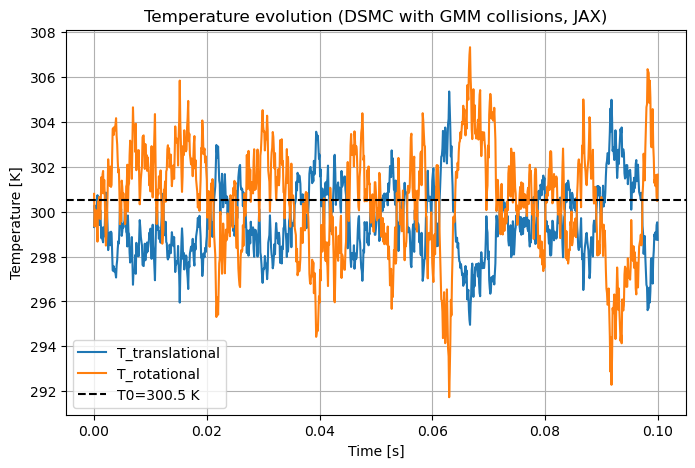

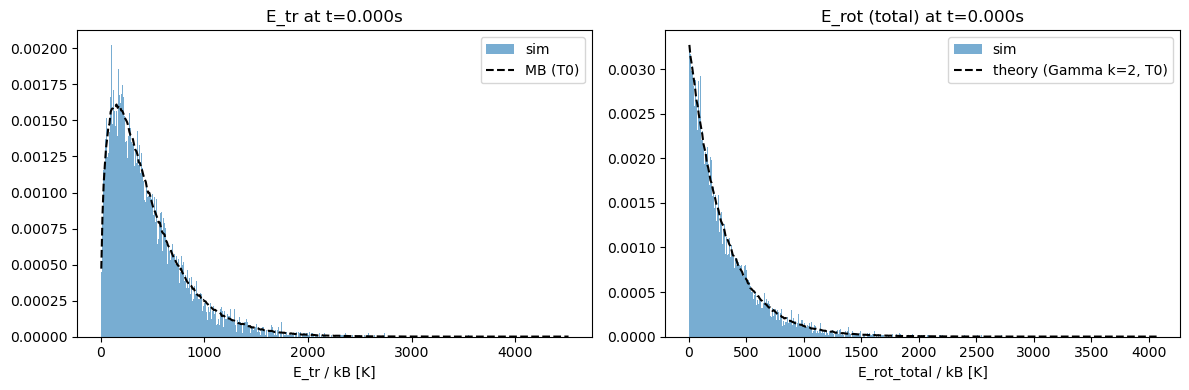

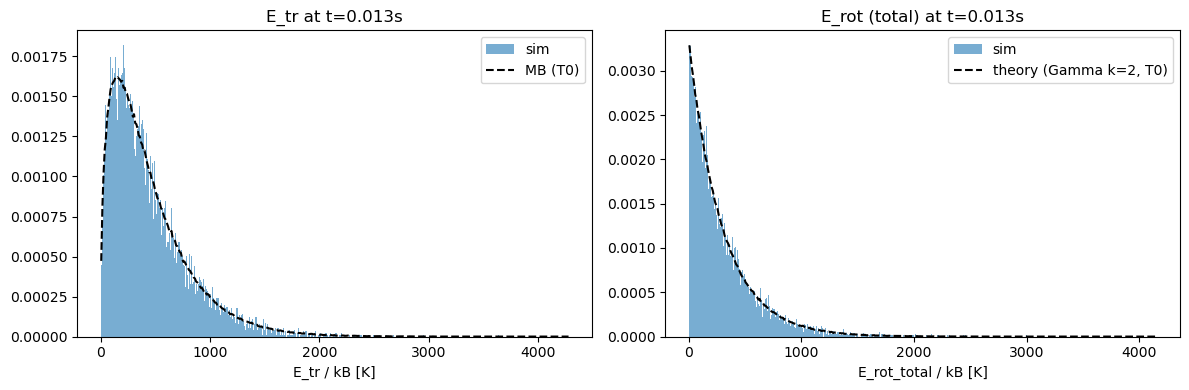

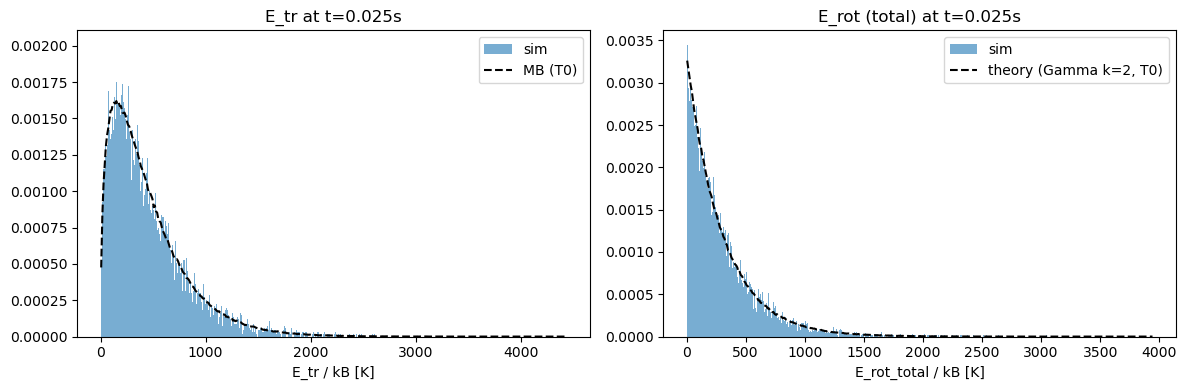

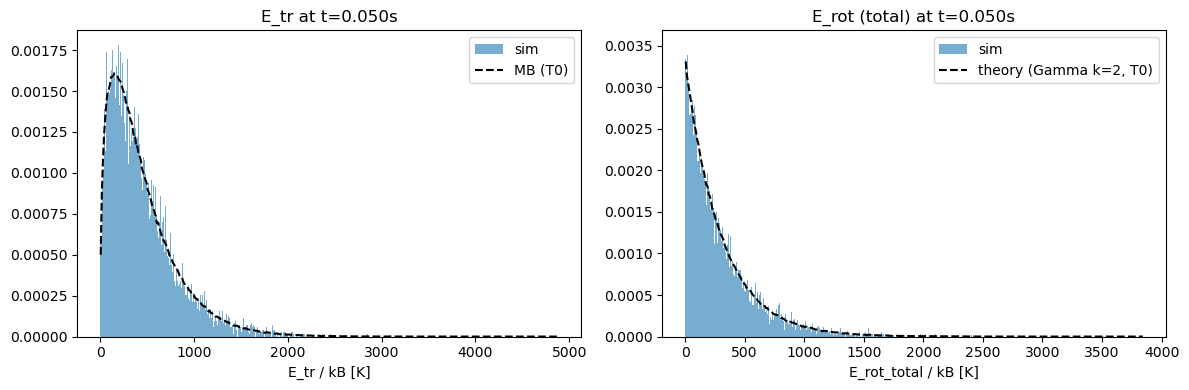

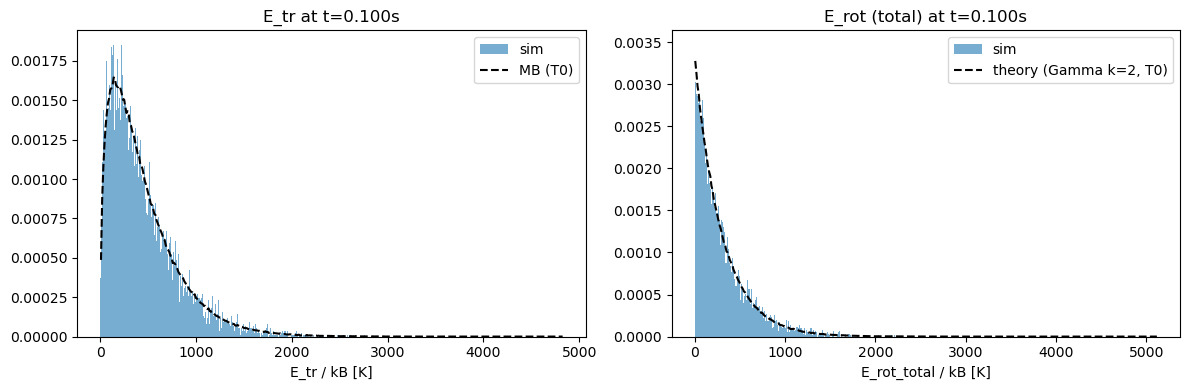

In [30]:

# ---------------------------
# Plot temperatures
# ---------------------------
T0=300.5
plt.figure(figsize=(8,5))
plt.plot(times, Ttr_list, label="T_translational")
plt.plot(times, Trot_list, label="T_rotational")
plt.axhline(T0, color="k", linestyle="--", label=f"T0={T0} K")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.title("Temperature evolution (DSMC with GMM collisions, JAX)")
plt.grid(True)
plt.show()

# ---------------------------
# Histograms at snapshots
# ---------------------------
def plot_energy_histograms(snapshot):
    t = snapshot["time"]
    v_tr_snap = snapshot["v_tr"]
    Etr_snap = 0.5 * m_molecule * np.sum(v_tr_snap**2, axis=1) / kB  # Kelvin units
    Erot_snap = snapshot["Er"] / kB

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # Translational
    ax = axes[0]
    ax.hist(Etr_snap, bins=400, density=True, alpha=0.6, label="sim")
    samp_v = maxwell.rvs(scale=np.sqrt(kB*T0/m_molecule), size=1000000)
    samp_E = 0.5 * m_molecule * samp_v**2 / kB
    hist_s, be = np.histogram(samp_E, bins=400, density=True)
    bc = 0.5*(be[:-1]+be[1:])
    ax.plot(bc, hist_s, 'k--', label="MB (T0)")
    ax.set_xlabel("E_tr / kB [K]")
    ax.set_title(f"E_tr at t={t:.3f}s")
    ax.legend()

    # Rotational
    ax = axes[1]
    ax.hist(Erot_snap, bins=400, density=True, alpha=0.6, label="sim")
    samp_rot = np.random.gamma(shape=1.0, scale=kB*T0, size=1000000) / kB
    hist_s_r, be_r = np.histogram(samp_rot, bins=400, density=True)
    bc_r = 0.5*(be_r[:-1]+be_r[1:])
    ax.plot(bc_r, hist_s_r, 'k--', label="theory (Gamma k=2, T0)")
    ax.set_xlabel("E_rot_total / kB [K]")
    ax.set_title(f"E_rot (total) at t={t:.3f}s")
    ax.legend()

    plt.tight_layout()
    plt.show()

for snap in snapshots:
    plot_energy_histograms(snap)